<a href="https://colab.research.google.com/github/fahimaislam2022/Python-/blob/main/1D_Logistic_Regression_using_sklearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Linear Regression cannot be used for yes/no type of outcomes since the output of LR can be over 1 or even negative. The avoid this we use sigmoid function which is a smooth function that has value between 0 and 1 which is used as probabilities.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("/content/Social_Network_Ads.csv")
x = df.iloc[:, 2:4]
y = df.iloc[:, 4]

df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [23]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30)

In [24]:
from sklearn.preprocessing import StandardScaler
x_sca = StandardScaler()
x_train = x_sca.fit_transform(x_train)
x_test = x_sca.transform(x_test)

In [25]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(random_state=42, C=1.0, penalty='l2')
clf.fit(x_train, y_train)

LogisticRegression(random_state=42)

In [26]:
y_pred = clf.predict(x_test)

In [27]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[70,  3],
       [18, 29]])

/tmp/ipykernel_1670/2737161825.py:4: UserWarning: The following kwargs were not used by contour: 'camp'
  plt.contourf(x1, x2, clf.predict(np.array([x1.ravel(), x2.ravel()]).T).reshape(x1.shape), alpha=0.75, camp=ListedColormap(('red', 'green')))
/tmp/ipykernel_1670/2737161825.py:6: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1], c=ListedColormap(('red','green'))(i), label=j, edgecolor='black')


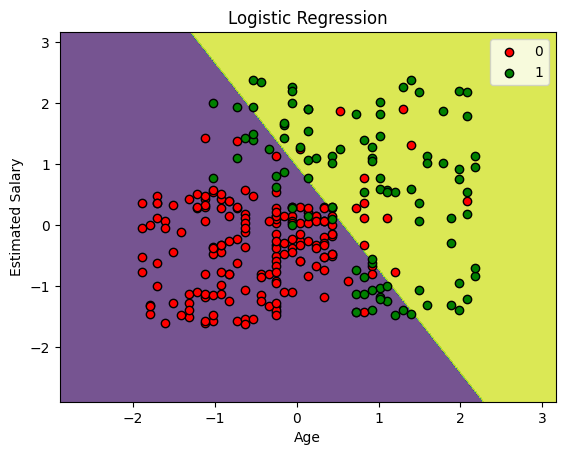

In [32]:
from matplotlib.colors import ListedColormap
x_set, y_set = x_train, y_train
x1, x2 = np.meshgrid(np.arange(start=x_set[:, 0].min() - 1, stop=x_set[:, 0].max() + 1, step=0.01), np.arange(start=x_set[:, 0].min() - 1, stop=x_set[:, 0].max() + 1, step=0.01))
plt.contourf(x1, x2, clf.predict(np.array([x1.ravel(), x2.ravel()]).T).reshape(x1.shape), alpha=0.75, camp=ListedColormap(('red', 'green')))
for i,j in enumerate(np.unique(y_pred)):
  plt.scatter(x_set[y_set == j, 0], x_set[y_set == j, 1], c=ListedColormap(('red','green'))(i), label=j, edgecolor='black')

plt.xlim(x1.min(), x1.max())
plt.ylim(x2.min(), x2.max())
plt.legend()
plt.title('Logistic Regression')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.show()

In [33]:
clf.score(x_test, y_test)

0.825